# PaySim Fraud Detection — Part 1: Exploratory Data Analysis

**Dataset:** PaySim — Synthetic Mobile Money Transactions  
**Goal:** Understand the data deeply through domain-driven hypotheses, not just descriptive statistics.  
**Key questions we will answer:**
1. What does the class imbalance look like, and what does it mean for modeling?
2. Which transaction types carry fraud, and why?
3. Is the bank's existing fraud flag (`isFlaggedFraud`) actually useful?
4. Do fraudulent transactions drain accounts to zero?
5. Are there balance inconsistencies that perfectly separate fraud from non-fraud?
6. Does fraud follow a temporal pattern?
7. What does fraudster account behavior look like vs. normal accounts?

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)
FRAUD_COLOR   = '#e74c3c'
NORMAL_COLOR  = '#2ecc71'
NEUTRAL_COLOR = '#3498db'

In [2]:
dtypes = {
    'step'           : 'int32',
    'amount'         : 'float32',
    'oldbalanceOrg'  : 'float32',
    'newbalanceOrig' : 'float32',
    'oldbalanceDest' : 'float32',
    'newbalanceDest' : 'float32',
    'isFraud'        : 'Int8',
    'isFlaggedFraud' : 'Int8',
    'type'           : 'category'
}

df = pd.read_csv('/home/aladdin/code/ml_projects/paysim-fraud-detection/data/raw/data.csv', dtype=dtypes)

In [3]:
print(f'Rows: {len(df)}:,')
print(f'Columns: {df.shape[1]}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')

Rows: 6362620:,
Columns: 11
Memory usage: 941.44 MB


## 1. Dataset Overview

PaySim is **synthetically generated** to simulate real mobile money transactions. There are no missing values by design — this is expected. The focus of EDA is therefore not cleaning but **behavioral pattern discovery**.

In [4]:
len(df)

6362620

In [5]:
df.info()
print('\n')
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        object  
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        object  
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         Int8    
 10  isFlaggedFraud  Int8    
dtypes: Int8(2), category(1), float32(5), int32(1), object(2)
memory usage: 273.1+ MB




,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,C1231006815,170136.0,160296.359375,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.280029,C1666544295,21249.0,19384.720703,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.000000,C1305486145,181.0,0.000000,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.000000,C840083671,181.0,0.000000,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.139648,C2048537720,41554.0,29885.859375,M1230701703,0.0,0.0,0,0


In [6]:
null_counts = df.isnull().sum()
null_counts

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
step,6362620.000000,243.397246,142.331971,1.000000,156.000000,239.000000,335.000000,743.000000
amount,6362620.000000,179861.890625,599135.750000,0.000000,13389.570312,74871.937500,208721.480469,92445520.000000
oldbalanceOrg,6362620.000000,833883.125000,2831752.750000,0.000000,0.000000,14208.000000,107315.175781,59585040.000000
newbalanceOrig,6362620.000000,855113.625000,2862818.500000,0.000000,0.000000,0.000000,144258.406250,49585040.000000
oldbalanceDest,6362620.000000,1100701.750000,3369337.500000,0.000000,0.000000,132705.664062,943036.687500,356015904.000000
newbalanceDest,6362620.000000,1224996.375000,3629806.500000,0.000000,0.000000,214661.445312,1111909.218750,356179264.000000
isFraud,6362620.000000,0.001291,0.035905,0.000000,0.000000,0.000000,0.000000,1.000000
isFlaggedFraud,6362620.000000,0.000003,0.001586,0.000000,0.000000,0.000000,0.000000,1.000000


- `amount` has a massive range (min 0, max in the millions): needs log scaling
- `step` has max 743 values, representing ~30 days of hourly data (743 / 24)
- Mean of `isFraud` is almost zero: imbalanced class

## 2. Class Imbalance Analysis

**Hypothesis:** Fraud is extremely rare — a naive model predicting "never fraud" would achieve >99% accuracy.

In [8]:
n_total = len(df)
n_fraud = len(df[df['isFraud'] == 1])
n_normal = n_total - n_fraud
fraud_pct = n_fraud / n_total * 100
no_fraud_pct = 100 - fraud_pct

print(f'Total transactions : {n_total:,}')
print(f'Fraud transactions : {n_fraud:,}  ({fraud_pct:.2f}%)')
print(f'Normal transactions: {n_normal:,}  ({no_fraud_pct:.2f}%)')
print()
print(f'Imbalance ratio: 1 fraud per every {n_normal // n_fraud:,} normal transactions')
print()
print('A model predicting never fraud achieves '
      f'{100 - fraud_pct:.2f}% accuracy — making accuracy meaningless, f1 score, AUC needed.')

Total transactions : 6,362,620
Fraud transactions : 8,213  (0.13%)
Normal transactions: 6,354,407  (99.87%)

Imbalance ratio: 1 fraud per every 773 normal transactions

A model predicting never fraud achieves 99.87% accuracy — making accuracy meaningless, f1 score, AUC needed.


### Visualizing imbalance

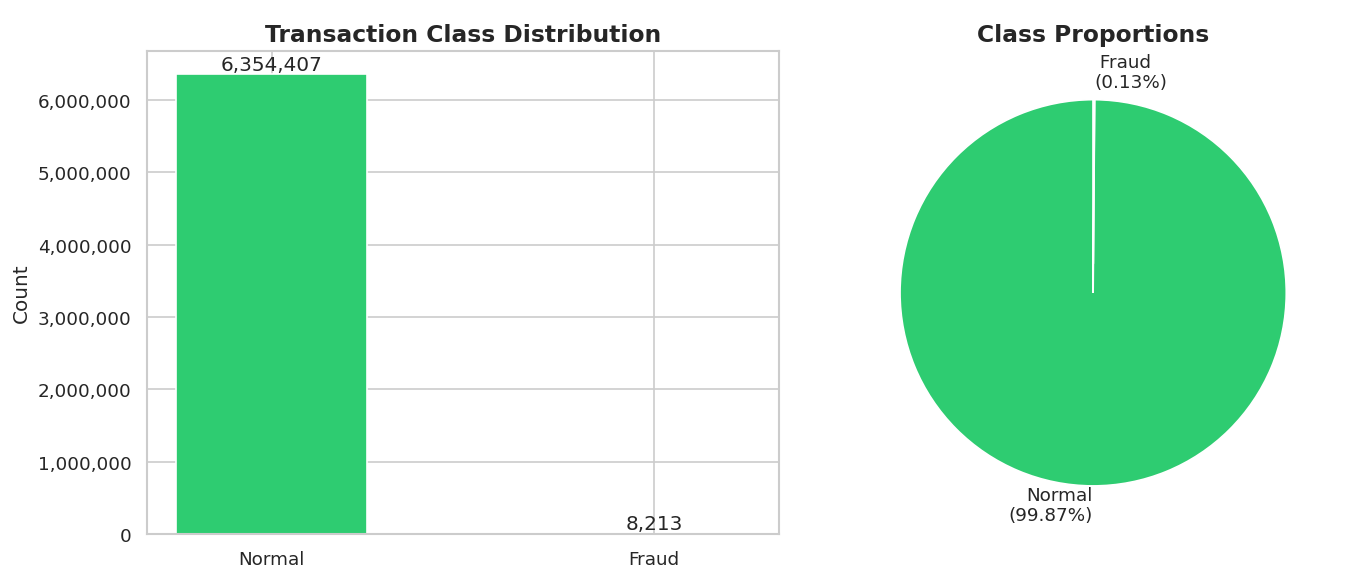

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
bars = axes[0].bar(['Normal', 'Fraud'], [n_normal, n_fraud],
                   color=[NORMAL_COLOR, FRAUD_COLOR], edgecolor='white', width=0.5)

axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter('{x:,.0f}')

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:,.0f}')

# pie chart
axes[1].pie([n_normal, n_fraud],
            labels=[f'Normal\n({no_fraud_pct:.2f}%)', f'\n\n Fraud\n({fraud_pct:.2f}%)'],
            colors=[NORMAL_COLOR, FRAUD_COLOR],
            startangle=90,
            explode=(0, 0.15))
axes[1].set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig('../reports/figures/01_class_imbalance.png')
plt.show()

## 3. Transaction Type Analysis

**Hypothesis:** Fraud does not occur in all transaction types — it is occurs only in TRANSFER and CASH_OUT.

In [10]:
type_stats = df.groupby('type', observed=True).agg(
    total = ('isFraud','count'),
    fraud = ('isFraud', 'sum'),
    fraud_pct = ('isFraud', lambda x: (x.mean()*100).round(2)),
    total_amount = ('amount', 'sum')
    ).sort_values('fraud', ascending=False).reset_index()
type_stats

,type,total,fraud,fraud_pct,total_amount
0,CASH_OUT,2237500,4116,0.18,3.944130e+11
1,TRANSFER,532909,4097,0.77,4.852920e+11
2,CASH_IN,1399284,0,0.00,2.363674e+11
3,DEBIT,41432,0,0.00,2.271992e+08
4,PAYMENT,2151495,0,0.00,2.809337e+10


### Visualizing transaction types

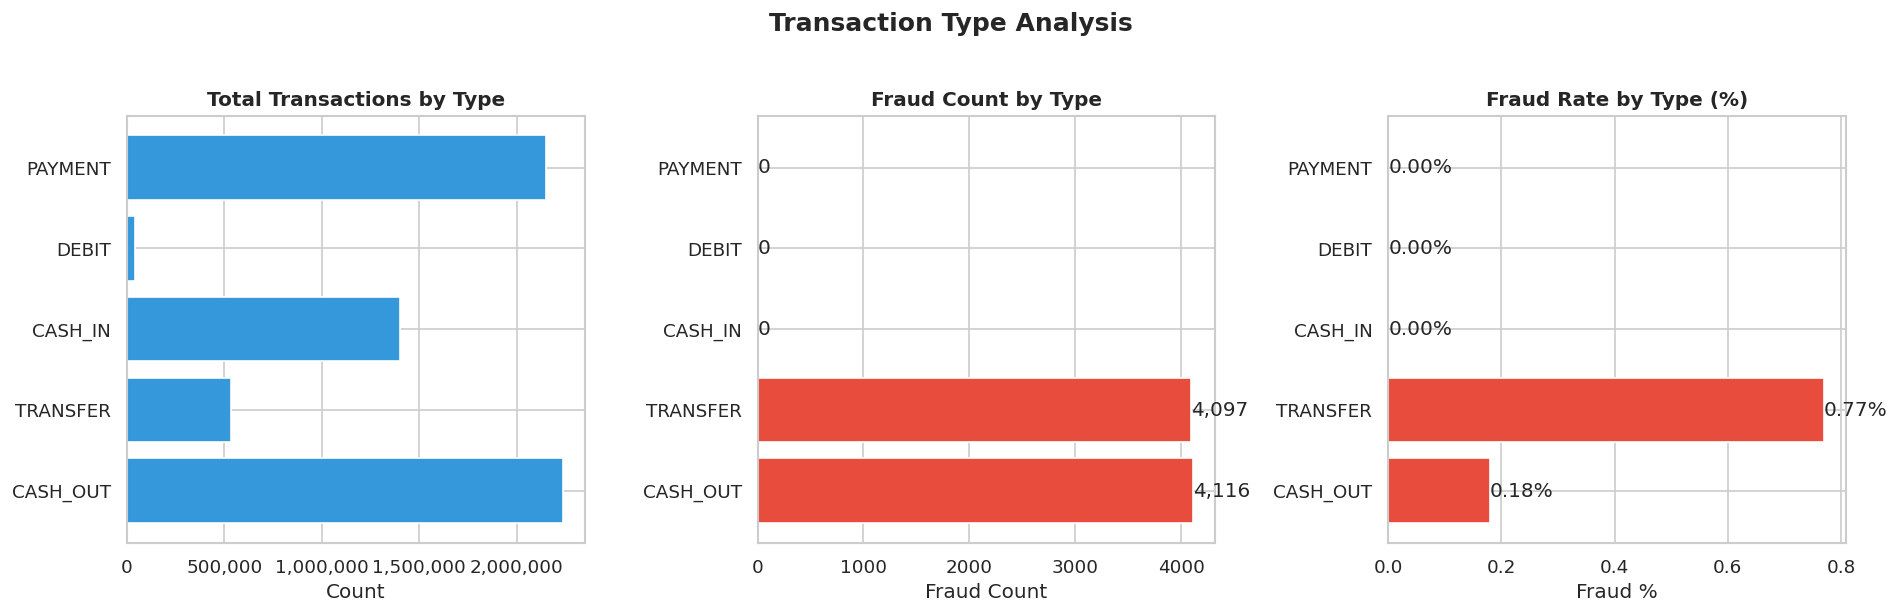

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# total volume per type
axes[0].barh(type_stats['type'], type_stats['total'], color=NEUTRAL_COLOR)
axes[0].set_title('Total Transactions by Type', fontweight='bold')
axes[0].xaxis.set_major_formatter('{x:,.0f}')
axes[0].set_xlabel('Count')

# fraud count per type
fraud_types = type_stats[type_stats['fraud'] > 0]
axes[1].barh(type_stats['type'], type_stats['fraud'], color=FRAUD_COLOR)
axes[1].set_title('Fraud Count by Type', fontweight='bold')
axes[1].set_xlabel('Fraud Count')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:,.0f}')

# fraud rate per type
axes[2].barh(type_stats['type'], type_stats['fraud_pct'], color=FRAUD_COLOR)
axes[2].set_title('Fraud Rate by Type (%)', fontweight='bold')
axes[2].set_xlabel('Fraud %')
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='{:,.2f}%')

plt.suptitle('Transaction Type Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('../reports/figures/02_type_analysis.png')
plt.show()

Fraud ONLY occurs in TRANSFER and CASH_OUT transactions. We can drop PAYMENT, CASH_IN, DEBIT rows during modeling

## 4. Chacking Bank's Existing Fraud Flag

**Hypothesis:** `isFlaggedFraud` is ineffective, missing most of real fraud cases.

In [12]:
caught       = ((df['isFraud'] == 1) & (df['isFlaggedFraud'] == 1)).sum()
missed       = ((df['isFraud'] == 1) & (df['isFlaggedFraud'] == 0)).sum()
false_alarms = ((df['isFraud'] == 0) & (df['isFlaggedFraud'] == 1)).sum()
true_normal  = ((df['isFraud'] == 0) & (df['isFlaggedFraud'] == 0)).sum()

recall_flag    = caught / n_fraud * 100
precision_flag = caught / (caught + false_alarms) * 100

print(f'Total fraud cases   : {n_fraud:,}')
print(f'Caught              : {caught:,} ({recall_flag:.2f}% recall)')
print(f'Missed              : {missed:,} ({100 - recall_flag:.2f}% missed!)')
print(f'False alarms        : {false_alarms}')
print(f'Flag precision      : {precision_flag:.1f}%')
print()
print(f'The bank misses {100 - recall_flag:.1f}% of all fraud.')
print(f'This is the business problem our model solves.')

Total fraud cases   : 8,213
Caught              : 16 (0.19% recall)
Missed              : 8,197 (99.81% missed!)
False alarms        : 0
Flag precision      : 100.0%

The bank misses 99.8% of all fraud.
This is the business problem our model solves.


### Visualizing Confussion Matrix

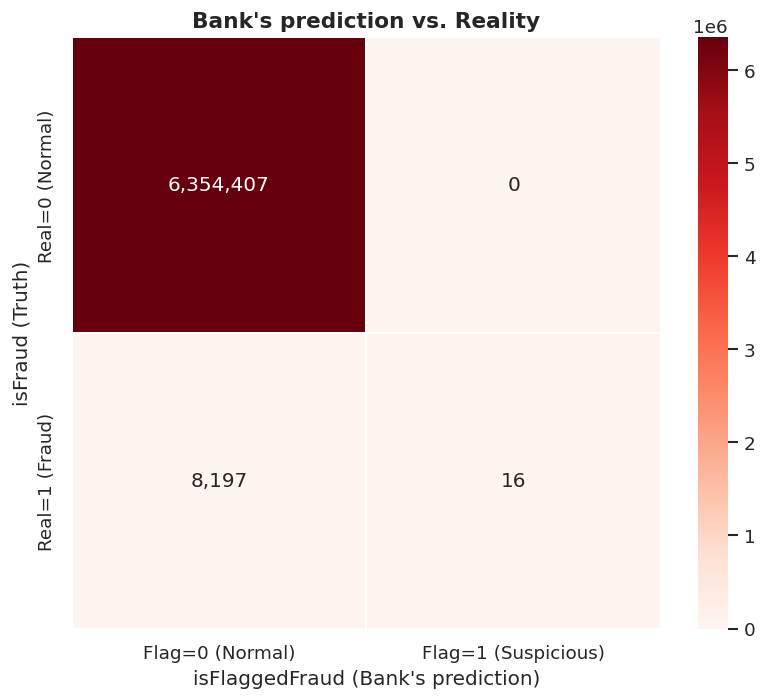

In [13]:
cm = np.array([[true_normal, false_alarms],
               [missed,       caught]])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=',', cmap='Reds',
            xticklabels=['Flag=0 (Normal)', 'Flag=1 (Suspicious)'],
            yticklabels=['Real=0 (Normal)', 'Real=1 (Fraud)'],
            linewidths=1, linecolor='white', ax=ax)
ax.set_title("Bank's prediction vs. Reality", fontsize=13, fontweight='bold')
ax.set_xlabel("isFlaggedFraud (Bank's prediction)")
ax.set_ylabel('isFraud (Truth)')
plt.tight_layout()
# plt.savefig('../reports/figures/03_flag_vs_fraud.png')
plt.show()

## 5. Amount Distribution Analysis

**Hypothesis:** Fraude transaction amounts follow a different distribution than normal transactions.

In [14]:
amount_stats = df.groupby('isFraud')['amount'].describe().round()
amount_stats.index=['Normal', 'Fraud']
amount_stats

,count,mean,std,min,25%,50%,75%,max
Normal,6354407.0,178197.0,591525.0,0.0,13368.0,74685.0,208365.0,92445520.0
Fraud,8213.0,1467967.0,2404254.0,0.0,127091.0,441423.0,1517772.0,10000000.0


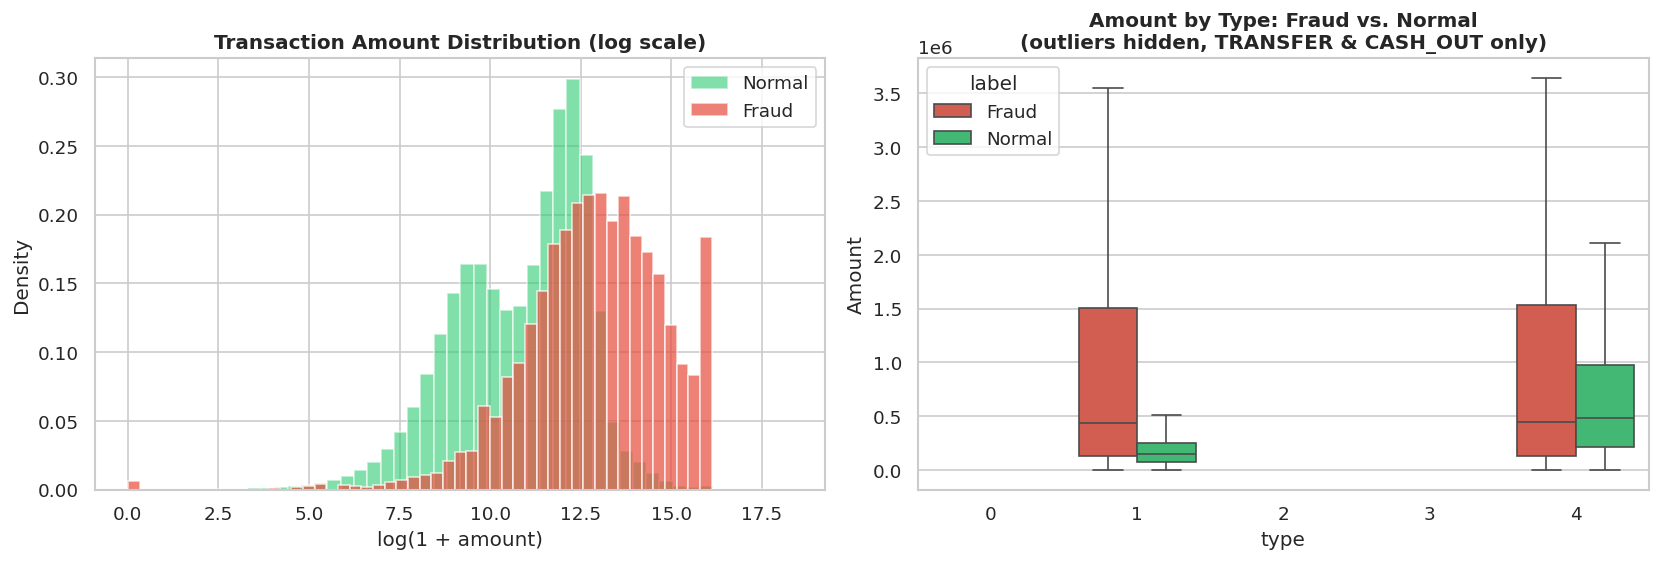

In [15]:
fraud_amounts  = df.loc[df['isFraud'] == 1]['amount']
normal_amounts = df.loc[df['isFraud'] == 0]['amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_fraud  = np.log1p(fraud_amounts)
log_normal = np.log1p(normal_amounts)

axes[0].hist(log_normal, bins=50, color=NORMAL_COLOR, alpha=0.6, label='Normal', density=True)
axes[0].hist(log_fraud,  bins=50, color=FRAUD_COLOR,  alpha=0.7, label='Fraud',  density=True)
axes[0].set_title('Transaction Amount Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('log(1 + amount)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot (TRANSFER and CASH_OUT)
subset = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
subset['label'] = subset['isFraud'].map({0: 'Normal', 1: 'Fraud'})

sns.boxplot(data=subset, x='type', y='amount', hue='label',
            palette={'Normal': NORMAL_COLOR, 'Fraud': FRAUD_COLOR},
            showfliers=False, ax=axes[1])
axes[1].set_title('Amount by Type: Fraud vs. Normal\n(outliers hidden, TRANSFER & CASH_OUT only)',
                  fontweight='bold')
axes[1].set_ylabel('Amount')
axes[1].xaxis.set_major_formatter('{x:,.0f}')

plt.tight_layout()
# plt.savefig('../reports/figures/04_amount_distribution.png')
plt.show()

In [16]:
max_fraud_amount = fraud_amounts.max()
pct_below_10M = (fraud_amounts < 10_000_000).mean() * 100

print(f'Max fraud amount         : {max_fraud_amount:,.2f}')
print(f'Fraud amounts < 10M      : {pct_below_10M:.1f}%')
print()

# percentile analysis
percentiles = [50, 75, 90, 95, 99, 100]
print('Fraud amount percentiles:')
for p in percentiles:
    print(f'  p{p:<3}:   {np.percentile(fraud_amounts, p):>15,.2f}')

Max fraud amount         : 10,000,000.00
Fraud amounts < 10M      : 96.5%

Fraud amount percentiles:
  p50 :        441,423.44
  p75 :      1,517,771.50
  p90 :      4,521,719.00
  p95 :      8,006,429.00
  p99 :     10,000,000.00
  p100:     10,000,000.00


## 6. Balance Drain Analysis

**Hypothesis:** Fraudsters drain the origin account to exactly zero.

In [17]:
df['zeroBalanceOrig'] = (df['newbalanceOrig'] == 0).astype('int8')

# rate of zero balance, by fraud label
zero_bal_rate = df.groupby('isFraud')['zeroBalanceOrig'].mean() * 100
zero_bal_rate.index = ['Normal', 'Fraud']

print('Rate of origin account drained to zero after transaction:')
for label, rate in zero_bal_rate.items():
    print(f' {label}: {rate:.2f}%')

Rate of origin account drained to zero after transaction:
 Normal: 56.68%
 Fraud: 98.05%


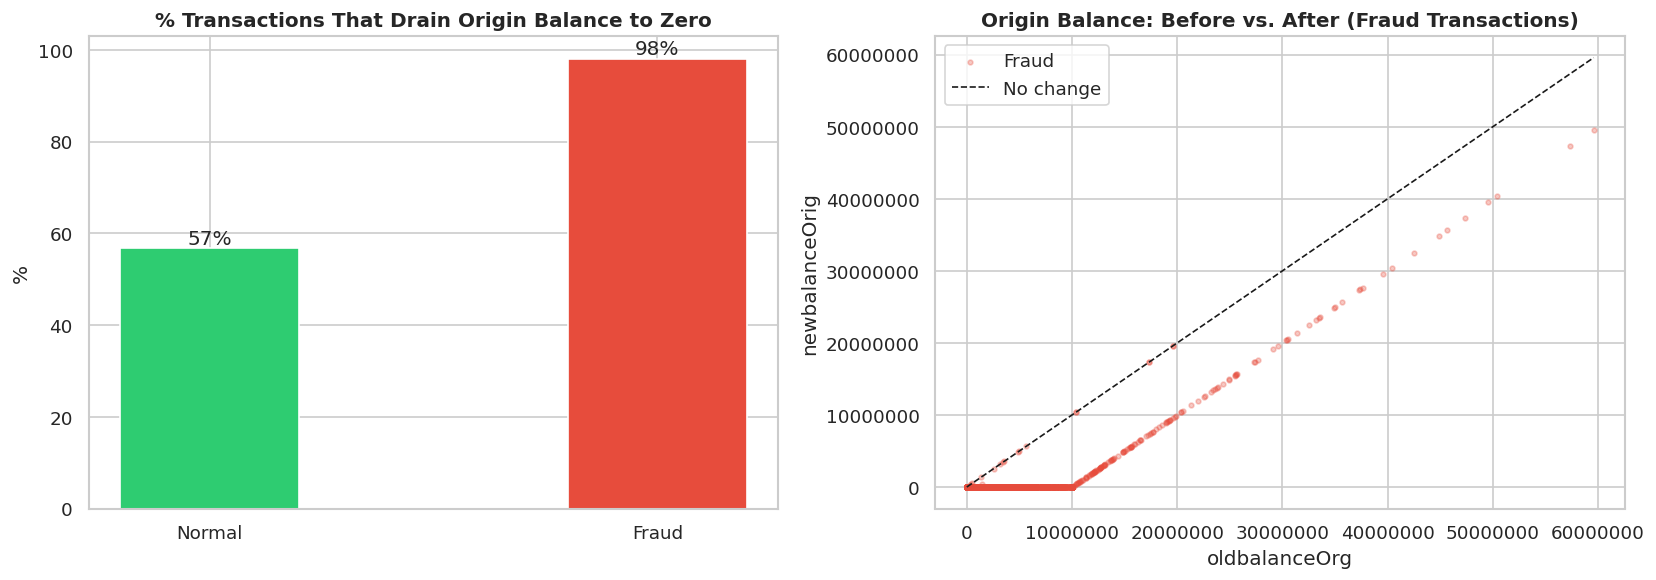

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# barplot
axes[0].bar(zero_bal_rate.index, zero_bal_rate.values,
            color=[NORMAL_COLOR, FRAUD_COLOR], edgecolor='white', width=0.4)
axes[0].set_title('% Transactions That Drain Origin Balance to Zero',
                  fontweight='bold')
axes[0].set_ylabel('%')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:,.0f}%')

# scatter plot
fraud_sample = df[df['isFraud'] == 1]
axes[1].scatter(fraud_sample['oldbalanceOrg'], fraud_sample['newbalanceOrig'],
                alpha=0.3, color=FRAUD_COLOR, s=8, label='Fraud')

# reference line: if no balance change
max_val = fraud_sample['oldbalanceOrg'].max()
axes[1].plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='No change')
axes[1].set_title('Origin Balance: Before vs. After (Fraud Transactions)',
                  fontweight='bold')
axes[1].ticklabel_format(style='plain', axis='both')
axes[1].set_xlabel('oldbalanceOrg')
axes[1].set_ylabel('newbalanceOrig')
axes[1].legend()

plt.tight_layout()
# plt.savefig('../reports/figures/05_balance_drain.png')
plt.show()

## 7. Balance Inconsistency — The Strongest Signal

**Hypothesis:** For non-fraud transactions, the balance change should exactly match the transaction amount. If `newbalanceOrig != oldbalanceOrg - amount`, something is off.

In [19]:
df['errorBalanceOrig'] = df['newbalanceOrig'] - (df['oldbalanceOrg'] - df['amount'])
df['errorBalanceDest'] = df['newbalanceDest'] - (df['oldbalanceDest'] + df['amount'])

# summary per class
error_stats = df.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].describe().round()
error_stats.index = ['Normal', 'Fraud']
error_stats

errorBalanceOrig                                                      \
                  count      mean       std  min     25%      50%       75%   
Normal        6354407.0  201339.0  600425.0 -4.0  3034.0  69049.0  249953.0   
Fraud            8213.0   10692.0  265144.0 -2.0     0.0      0.0       0.0   

                   errorBalanceDest                                   \
               max            count      mean        std         min   
Normal  92445520.0        6354407.0  -54692.0   433393.0 -13191234.0   
Fraud   10000000.0           8213.0 -732509.0  1867768.0 -10000000.0   

                                           
             25%     50%  75%         max  
Normal  -29260.0 -3501.0  0.0  75885720.0  
Fraud  -442722.0 -2231.0  0.0   8875517.0

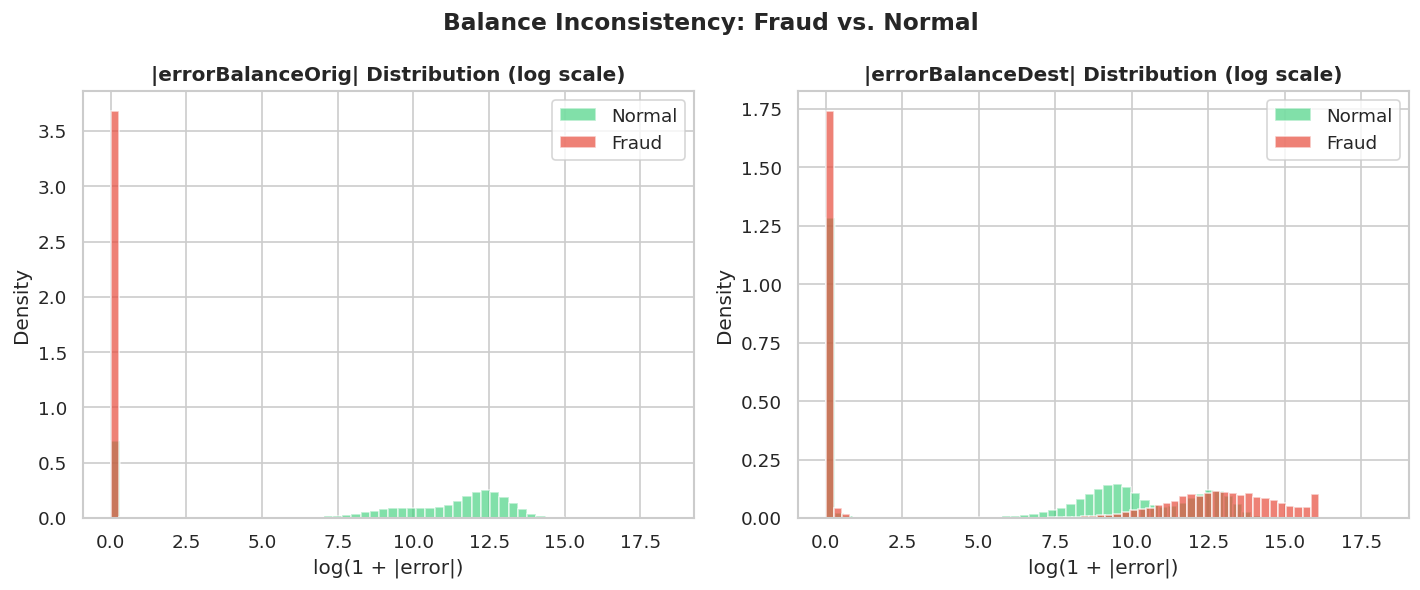

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(['errorBalanceOrig', 'errorBalanceDest']):
    fraud_log  = np.log1p(np.abs(df.loc[df['isFraud'] == 1][col]))
    normal_log = np.log1p(np.abs(df.loc[df['isFraud'] == 0][col]))

    axes[i].hist(normal_log, bins=60, alpha=0.6, color=NORMAL_COLOR,
                 density=True, label='Normal')
    axes[i].hist(fraud_log,  bins=60, alpha=0.7, color=FRAUD_COLOR,
                 density=True, label='Fraud')
    axes[i].set_title(f'|{col}| Distribution (log scale)', fontweight='bold')
    axes[i].set_xlabel('log(1 + |error|)')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Balance Inconsistency: Fraud vs. Normal', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('../reports/figures/06_balance_error.png', bbox_inches='tight')
plt.show()

## 8. Temporal Analysis

**Hypothesis:** Fraud is not uniformly distributed across time.

In [21]:
temporal = df.groupby('step').agg(
    total      = ('isFraud', 'count'),
    fraud      = ('isFraud', 'sum'),
    fraud_rate = ('isFraud', lambda x: (x.mean() * 100).round(2))
).reset_index()

temporal['hour_of_day'] = temporal['step'] % 24

print(f'Peak fraud at step: {temporal.loc[temporal["fraud"].idxmax(), "step"]}')

Peak fraud at step: 212


In [22]:
temporal.set_index('step').head(3)

,total,fraud,fraud_rate,hour_of_day
step,,,,
1,2708,16,0.59,1
2,1014,8,0.79,2
3,552,4,0.72,3


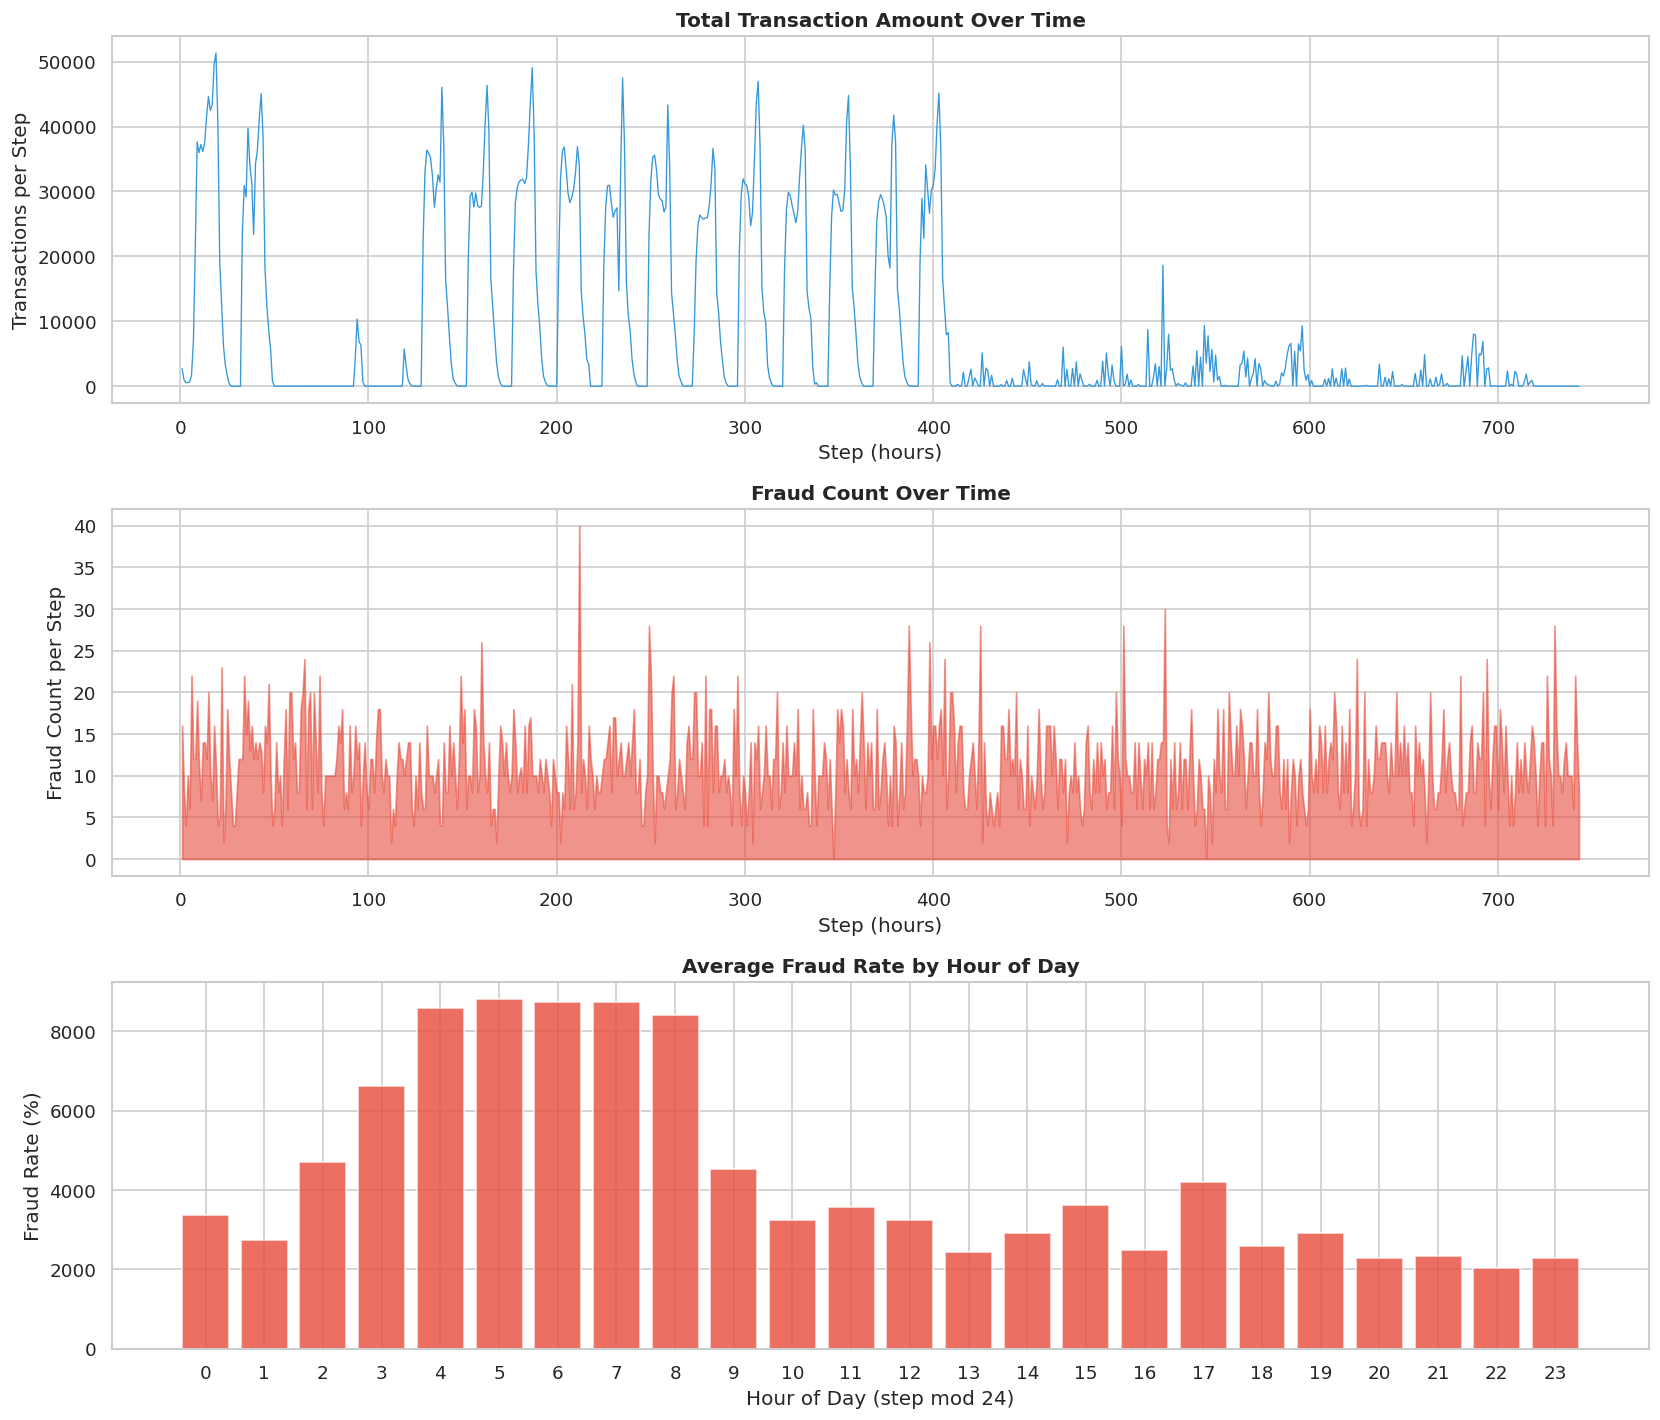

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# total transaction count
axes[0].plot(temporal['step'], temporal['total'], color=NEUTRAL_COLOR, linewidth=0.8)
axes[0].set_title('Total Transaction Amount Over Time', fontweight='bold')
axes[0].set_ylabel('Transactions per Step')
axes[0].set_xlabel('Step (hours)')

# fraud count over time
axes[1].fill_between(temporal['step'], temporal['fraud'], color=FRAUD_COLOR, alpha=0.6)
axes[1].set_title('Fraud Count Over Time', fontweight='bold')
axes[1].set_ylabel('Fraud Count per Step')
axes[1].set_xlabel('Step (hours)')

# fraud rate by hour of day
hourly = temporal.groupby('hour_of_day').agg(
    avg_fraud_rate = ('fraud_rate', 'mean'),
    total_fraud    = ('fraud', 'sum')
).reset_index()

axes[2].bar(hourly['hour_of_day'], hourly['avg_fraud_rate'] * 100,
            color=FRAUD_COLOR, alpha=0.8)
axes[2].set_title('Average Fraud Rate by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour of Day (step mod 24)')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].set_xticks(range(24))

plt.tight_layout()
# plt.savefig('../reports/figures/07_temporal_analysis.png', bbox_inches='tight')
plt.show()

## 9. Account Behavior Analysis

**Hypothesis:** Fraud accounts make very few transactions, normal accounts have more transaction history.

In [24]:
account_stats = df.groupby('nameOrig').agg(
    n_transactions = ('step', 'count'),
    is_fraudster   = ('isFraud', 'max')
).reset_index()

fraudster_trn_count  = account_stats.loc[account_stats['is_fraudster'] == 1]['n_transactions']
normal_trn_count     = account_stats.loc[account_stats['is_fraudster'] == 0]['n_transactions']

print(f'Fraudster accounts: mean={fraudster_trn_count.mean():.2f}, '
      f'median={fraudster_trn_count.median():.2f}, max={fraudster_trn_count.max()}')
print(f'Normal accounts: mean={normal_trn_count.mean():.2f}, '
      f'median={normal_trn_count.median():.2f}, max={normal_trn_count.max()}')
print()
print(f'% normal accounts with exactly 1 transaction: '
      f'{(normal_trn_count == 1).mean() * 100:.2f}%')
print(f'% fraudster accounts with exactly 1 transaction: '
      f'{(fraudster_trn_count == 1).mean() * 100:.2f}%')

Fraudster accounts: mean=1.00, median=1.00, max=2
Normal accounts: mean=1.00, median=1.00, max=3

% normal accounts with exactly 1 transaction: 99.85%
% fraudster accounts with exactly 1 transaction: 99.66%


In [25]:
account_stats[account_stats['n_transactions'] == 1]

,nameOrig,n_transactions,is_fraudster
0,C1000000639,1,0
1,C1000001337,1,0
2,C1000001725,1,0
3,C1000002591,1,0
4,C1000003372,1,0
...,...,...,...
6353302,C999996999,1,0
6353303,C999998175,1,0
6353304,C999999254,1,0
6353305,C999999614,1,0


In [26]:
account_stats.head()

,nameOrig,n_transactions,is_fraudster
0,C1000000639,1,0
1,C1000001337,1,0
2,C1000001725,1,0
3,C1000002591,1,0
4,C1000003372,1,0


In [27]:
len(df) - len(account_stats)

9313

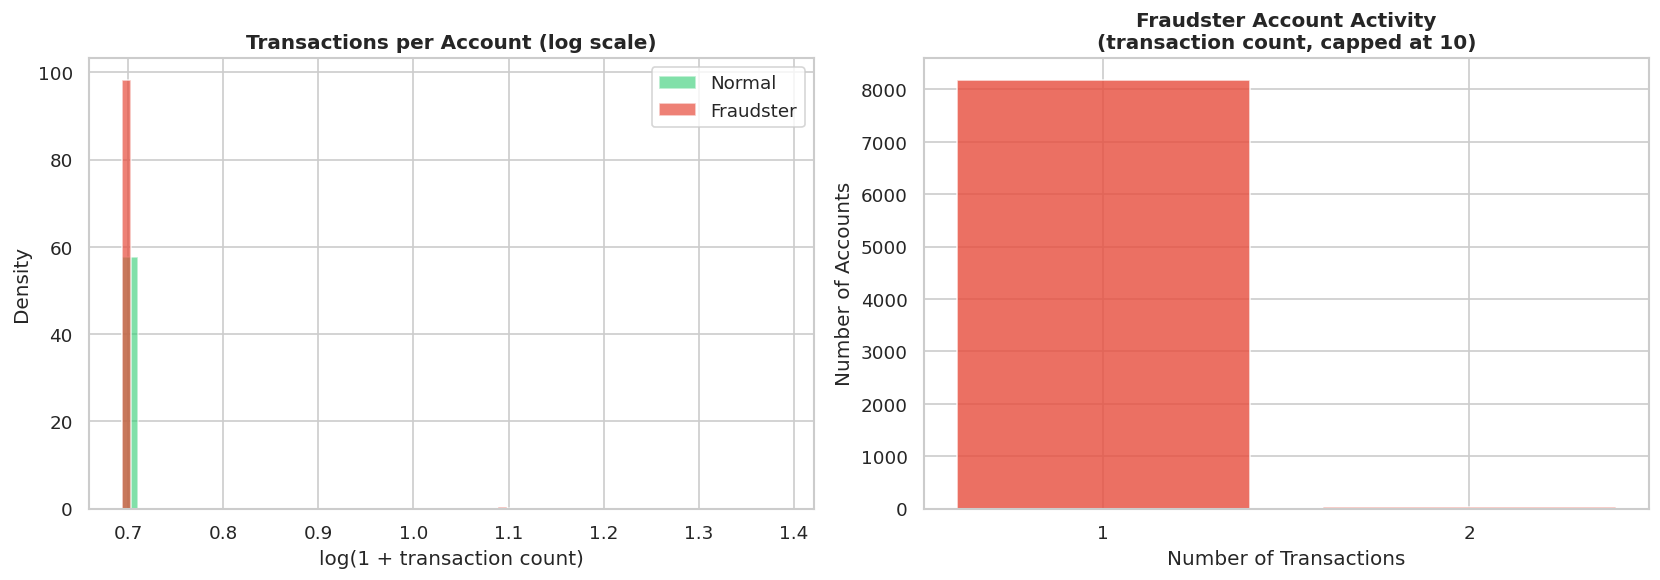

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(normal_trn_count), bins=40, color=NORMAL_COLOR,
             alpha=0.6, density=True, label='Normal')
axes[0].hist(np.log1p(fraudster_trn_count), bins=40, color=FRAUD_COLOR,
             alpha=0.7, density=True, label='Fraudster')
axes[0].set_title('Transactions per Account (log scale)', fontweight='bold')
axes[0].set_xlabel('log(1 + transaction count)')
axes[0].set_ylabel('Density')
axes[0].legend()

capped = fraudster_trn_count.clip(upper=5).value_counts().sort_index()
axes[1].bar(capped.index.astype(str), capped.values, color=FRAUD_COLOR, alpha=0.8)
axes[1].set_title('Fraudster Account Activity\n(transaction count, capped at 10)',
                  fontweight='bold')
axes[1].set_xlabel('Number of Transactions')
axes[1].set_ylabel('Number of Accounts')

plt.tight_layout()
# plt.savefig('../reports/figures/08_account_behavior.png')
plt.show()

## 10. Destination Account Analysis

**Hypothesis:** Fraudulent destination accounts receive money from many different sources, while normal destinations interact with fewer senders.

In [29]:
dest_stats = df.groupby('nameDest').agg(
    unique_senders = ('nameOrig', 'nunique'),
    total_received = ('amount', 'sum'),
    fraud_received = ('isFraud', 'sum')
).reset_index()

dest_stats['is_fraud_dest'] = (dest_stats['fraud_received'] > 0).astype(int)

fraud_dest_senders  = dest_stats.loc[dest_stats['is_fraud_dest'] == 1, 'unique_senders']
normal_dest_senders = dest_stats.loc[dest_stats['is_fraud_dest'] == 0, 'unique_senders']

print(f'Fraud destination  : mean={fraud_dest_senders.mean():.2f}, '
      f'median={fraud_dest_senders.median():.2f}')
print(f'Normal destination : mean={normal_dest_senders.mean():.2f}, '
      f'median={normal_dest_senders.median():.2f}')
print()

print('Top 10 fraud destination accounts by total amount received:')
top_fraud_dest = (
    dest_stats[dest_stats['is_fraud_dest'] == 1]
    .sort_values('total_received', ascending=False)
    .head(10)[['nameDest', 'unique_senders', 'total_received', 'fraud_received']]
)
top_fraud_dest

Fraud destination  : mean=8.04, median=4.00
Normal destination : mean=2.32, median=1.00

Top 10 fraud destination accounts by total amount received:


,nameDest,unique_senders,total_received,fraud_received
468443,C65111466,22,227443840.0,1
513758,C803116137,77,119151664.0,2
122368,C141316671,46,108729800.0,1
425720,C505864940,30,94620456.0,1
168803,C1570256460,63,91382936.0,1
473251,C667346055,86,84963440.0,1
282421,C1954217280,27,70847040.0,1
421601,C491626410,26,67041908.0,1
125285,C1423246212,25,66209352.0,1
142809,C1481851679,67,64122928.0,1


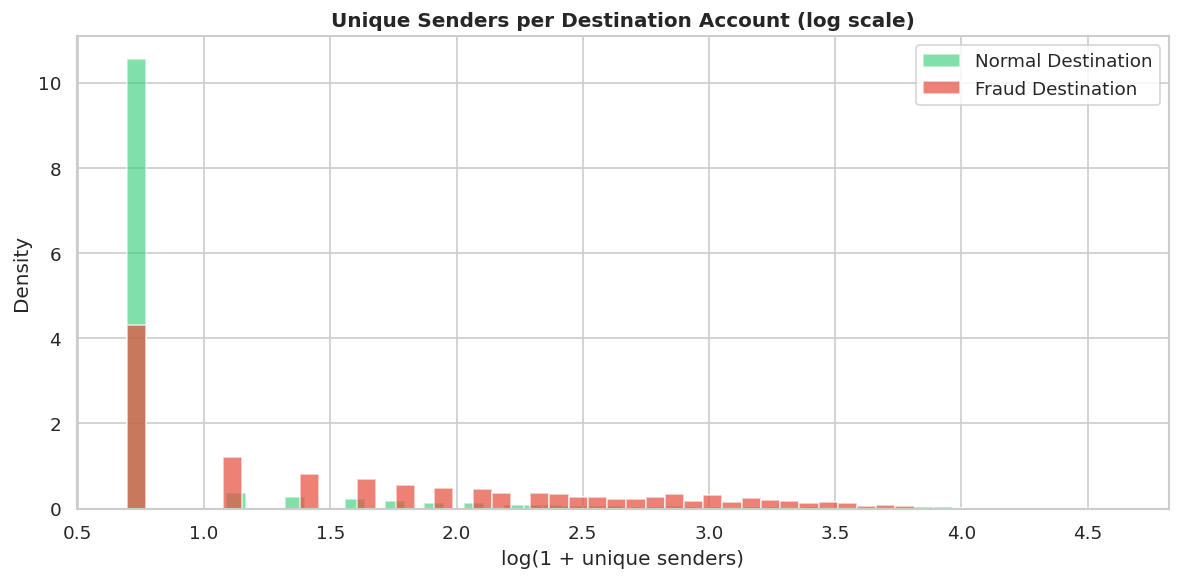

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(np.log1p(normal_dest_senders.sample(min(50000, len(normal_dest_senders)), random_state=42)),
        bins=50, color=NORMAL_COLOR, alpha=0.6, density=True, label='Normal Destination')
ax.hist(np.log1p(fraud_dest_senders),
        bins=50, color=FRAUD_COLOR,  alpha=0.7, density=True, label='Fraud Destination')
ax.set_title('Unique Senders per Destination Account (log scale)',
             fontweight='bold')
ax.set_xlabel('log(1 + unique senders)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
# plt.savefig('../reports/figures/09_dest_fanin.png', bbox_inches='tight')
plt.show()

## 11. Correlation Analysis

Linear relationships between numerical features and the fraud label.

In [32]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest']

# 1. Calculate correlations for all columns at once and round to 4 decimals
corr_series = df[numeric_cols].corrwith(df['isFraud']).round(4)

# 2. Sort by absolute value and turn it into a neat DataFrame for printing
corr_df = corr_series.sort_values(key=abs, ascending=False).to_frame(name='correlation')

print('Correlation with isFraud:')
print(corr_df)

Correlation with isFraud:
                  correlation
amount                 0.0767
errorBalanceDest      -0.0551
step                   0.0316
errorBalanceOrig      -0.0113
oldbalanceOrg          0.0102
newbalanceOrig        -0.0081
oldbalanceDest        -0.0059
newbalanceDest         0.0005


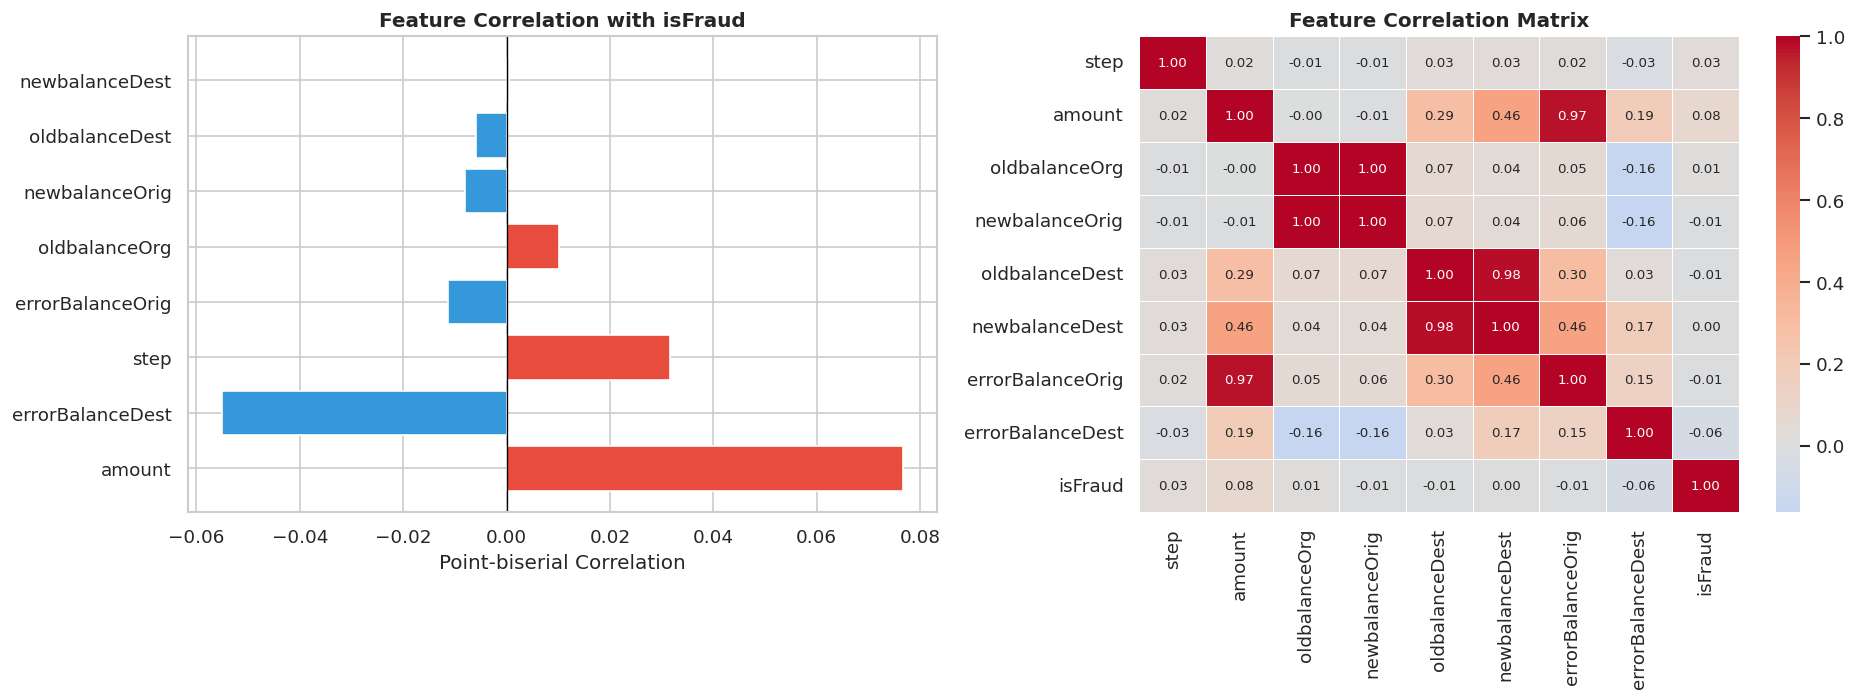

In [33]:
# ── feature correlation heatmap ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# bar chart of correlations with isFraud
colors = [FRAUD_COLOR if c > 0 else NEUTRAL_COLOR for c in corr_df['correlation']]
axes[0].barh(corr_df.index, corr_df['correlation'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with isFraud', fontweight='bold')
axes[0].set_xlabel('Point-biserial Correlation')

# full correlation heatmap
corr_matrix = df[numeric_cols + ['isFraud']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/10_correlations.png', bbox_inches='tight')
plt.show()

In [34]:
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest']

corr_df = (df[numeric_cols].corrwith(df['isFraud']).round(4)
    .rename('correlation').sort_values(ascending=False).to_frame()
)
corr_df

,correlation
amount,0.0767
step,0.0316
oldbalanceOrg,0.0102
newbalanceDest,0.0005
oldbalanceDest,-0.0059
newbalanceOrig,-0.0081
errorBalanceOrig,-0.0113
errorBalanceDest,-0.0551


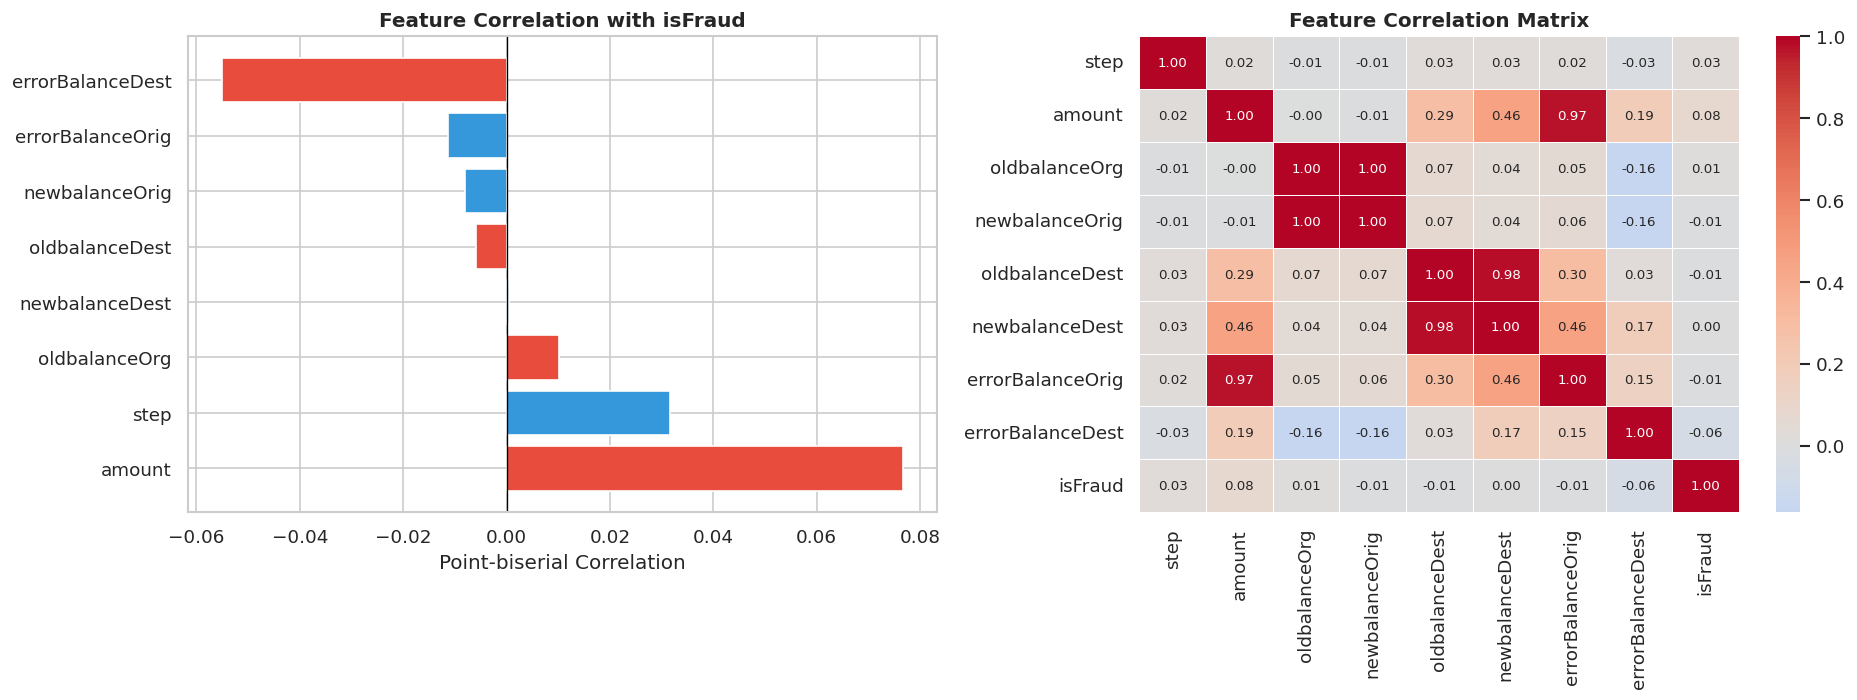

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar chart
axes[0].barh(corr_df.index, corr_df['correlation'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with isFraud', fontweight='bold')
axes[0].set_xlabel('Point-biserial Correlation')

# 2. Full correlation heatmap
corr_matrix = df[numeric_cols + ['isFraud']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
# plt.savefig('../reports/figures/10_correlations.png')
plt.show()

## 12. EDA Summary — Key Findings

This cell consolidates everything discovered above into a narrative summary. This is what you'd present to a business stakeholder — or include in your project README.

In [36]:
print('EDA SUMMARY — PaySim Fraud Detection')

print(f"""
DATASET
  {n_total:,} transactions over ~30 days of simulated mobile money activity.
  No missing values (synthetic dataset by design).

CLASS IMBALANCE
  Only {fraud_pct:.4f}% of transactions are fraudulent ({n_fraud:,} cases).
  An 'always predict normal' model achieves {100 - fraud_pct:.2f}% accuracy.
  Accuracy is a useless metric. Use Precision-Recall AUC.

TRANSACTION TYPES
  Fraud ONLY occurs in TRANSFER and CASH_OUT transactions.
  PAYMENT, CASH_IN, and DEBIT have zero fraud cases.

BANK SYSTEM FAILURE
  The bank's isFlaggedFraud system catches only {recall_flag:.2f}% of real fraud ({caught:,} / {n_fraud:,}).
  It misses {100 - recall_flag:.1f}% of all fraud — {missed:,} cases go undetected.

BALANCE DRAIN PATTERN
  Fraudulent transactions drain origin accounts to zero at a significantly
  higher rate than normal transactions.
  zeroBalanceOrig is a strong binary feature.

STRONGEST SIGNAL: BALANCE INCONSISTENCY
  errorBalanceOrig = newbalanceOrig - (oldbalanceOrg - amount)
  This value is near-zero for normal transactions but large for fraud.
  This will probably be the #1 feature importance in the model (verify via SHAP).

TEMPORAL PATTERNS
  Fraud is not uniformly distributed — it clusters at specific hours.
  step and hour_of_day are useful time-based features.

ACCOUNT BEHAVIOR
  Fraud destination accounts receive from many unique senders.

""")

EDA SUMMARY — PaySim Fraud Detection

DATASET
  6,362,620 transactions over ~30 days of simulated mobile money activity.
  No missing values (synthetic dataset by design).

CLASS IMBALANCE
  Only 0.1291% of transactions are fraudulent (8,213 cases).
  An 'always predict normal' model achieves 99.87% accuracy.
  Accuracy is a useless metric. Use Precision-Recall AUC.

TRANSACTION TYPES
  Fraud ONLY occurs in TRANSFER and CASH_OUT transactions.
  PAYMENT, CASH_IN, and DEBIT have zero fraud cases.

BANK SYSTEM FAILURE
  The bank's isFlaggedFraud system catches only 0.19% of real fraud (16 / 8,213).
  It misses 99.8% of all fraud — 8,197 cases go undetected.

BALANCE DRAIN PATTERN
  Fraudulent transactions drain origin accounts to zero at a significantly
  higher rate than normal transactions.
  zeroBalanceOrig is a strong binary feature.

STRONGEST SIGNAL: BALANCE INCONSISTENCY
  errorBalanceOrig = newbalanceOrig - (oldbalanceOrg - amount)
  This value is near-zero for normal transactions